
# Customer Segmentation Analysis

### Clustering customers by age, income, and spending score

This notebook presents a cleaner and more polished version of the clustering workflow using three methods:

- **K-Means**
- **Agglomerative Clustering**
- **DBSCAN**

The goal is to identify meaningful customer groups based on:

- **Age**
- **Annual Income**
- **Spending Score**



## 1. Setup

We begin by importing the required libraries and defining a few plotting settings for a more consistent look.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11



## 2. Load and Prepare the Data

This section loads the dataset, checks for missing values, imputes missing numeric values using the median, and standardizes the clustering features.


In [2]:


df = pd.read_csv("E:\\customers.csv")

print(f"Shape: {df.shape}")
df.head()


Shape: (219, 5)


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19.0,15.0,39.0
1,2,Male,21.0,15.0,81.0
2,3,Female,20.0,16.0,6.0
3,4,Female,23.0,16.0,77.0
4,5,Female,31.0,17.0,40.0


In [3]:

print("Missing values by column:")
display(df.isnull().sum().to_frame("missing_values"))

features = ["Age", "Annual_Income", "Spending_Score"]

imputer = SimpleImputer(strategy="median")
df[features] = imputer.fit_transform(df[features])

scaler = StandardScaler()
scaled_array = scaler.fit_transform(df[features])
df_scaled = pd.DataFrame(scaled_array, columns=features)

display(df[features].describe().T)


Missing values by column:


,missing_values
CustomerID,0
Gender,2
Age,3
Annual_Income,1
Spending_Score,1


,count,mean,std,min,25%,50%,75%,max
Age,219.0,38.114155,13.706984,18.0,28.0,35.0,48.0,70.0
Annual_Income,219.0,62.625571,27.740714,15.0,42.0,62.0,78.0,141.0
Spending_Score,219.0,50.251142,25.693606,1.0,34.5,50.0,72.5,99.0



## 3. K-Means Clustering

We use the elbow method to estimate a good value for **k**, then fit the K-Means model and visualize the resulting customer groups.


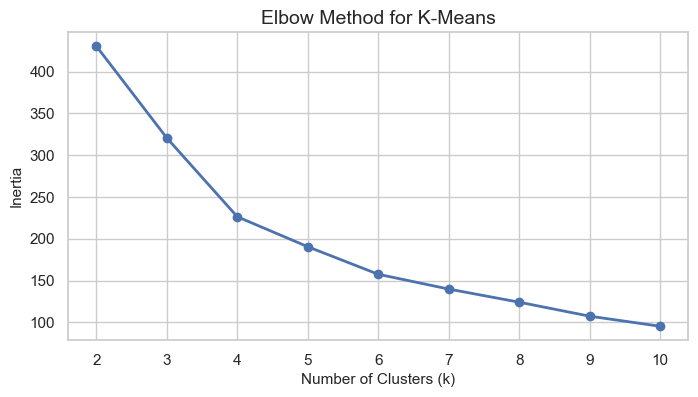

In [4]:

inertia = []
K_range = range(2, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker="o", linewidth=2)
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(K_range))
plt.show()


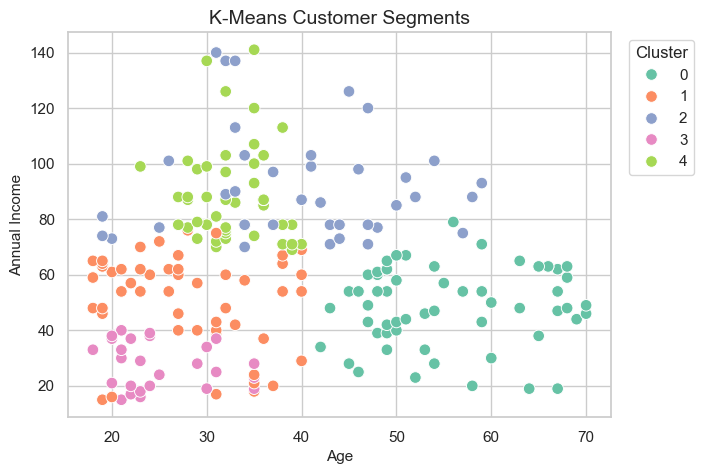

In [5]:

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

df["KMeans_Cluster"] = kmeans_labels

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Annual_Income",
    hue="KMeans_Cluster",
    palette="Set2",
    s=70,
)
plt.title("K-Means Customer Segments")
plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()



## 4. Agglomerative Clustering

Next, we examine the hierarchical structure of the data using a dendrogram and then fit an agglomerative clustering model.


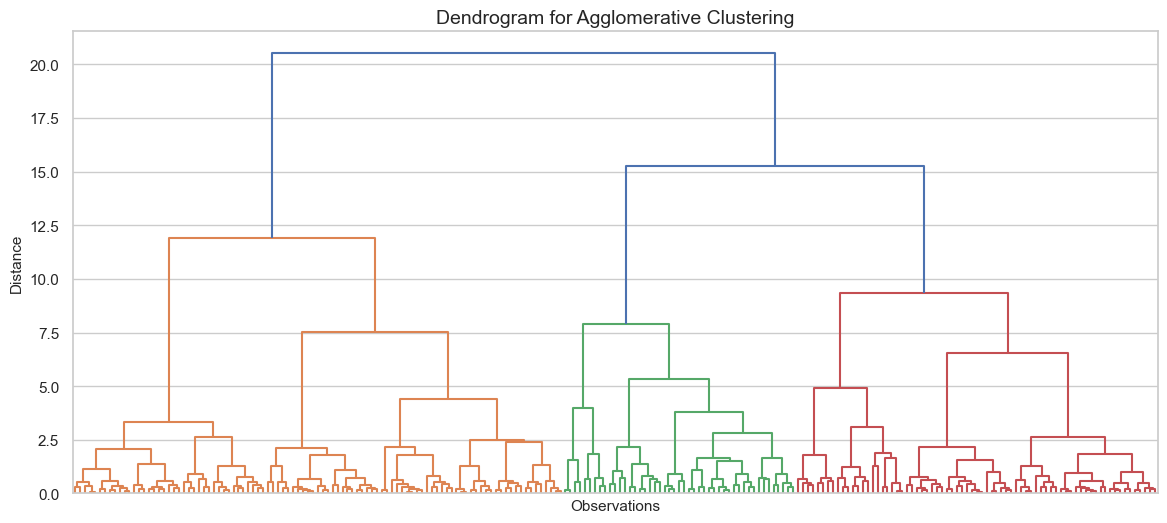

In [6]:

linked = linkage(df_scaled, method="ward")

plt.figure(figsize=(14, 6))
dendrogram(linked, no_labels=True)
plt.title("Dendrogram for Agglomerative Clustering")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()


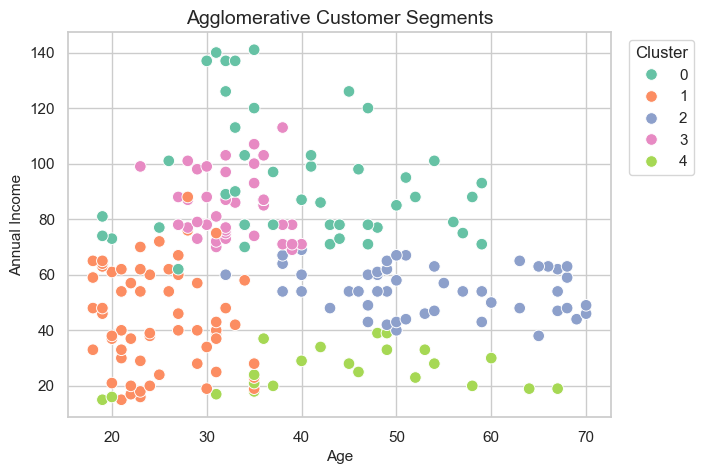

In [7]:

agg = AgglomerativeClustering(n_clusters=5)
agg_labels = agg.fit_predict(df_scaled)

df["Agglomerative_Cluster"] = agg_labels

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Annual_Income",
    hue="Agglomerative_Cluster",
    palette="Set2",
    s=70,
)
plt.title("Agglomerative Customer Segments")
plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()



## 5. DBSCAN Clustering

DBSCAN is useful when clusters may have irregular shapes and when identifying noise points is important.


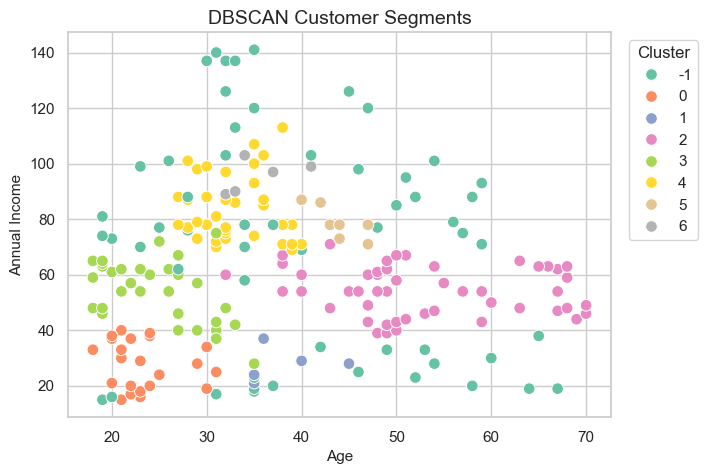

In [8]:

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(df_scaled)

df["DBSCAN_Cluster"] = dbscan_labels.astype(int)

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Annual_Income",
    hue="DBSCAN_Cluster",
    palette="Set2",
    s=70,
)
plt.title("DBSCAN Customer Segments")
plt.xlabel("Age")
plt.ylabel("Annual Income")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()



## 6. Model Comparison

We compare the clustering methods using:

- **Silhouette Score** for cluster separation
- **Cluster sizes** to understand group balance


In [9]:

def safe_silhouette_score(X, labels):
    unique_labels = set(labels)
    # Need at least 2 clusters, excluding the case where every point is noise or single-cluster output
    if len(unique_labels) <= 1:
        return np.nan
    if len(unique_labels) == 2 and -1 in unique_labels:
        return np.nan
    return silhouette_score(X, labels)

comparison = pd.DataFrame(
    {
        "Method": ["K-Means", "Agglomerative", "DBSCAN"],
        "Silhouette Score": [
            silhouette_score(df_scaled, kmeans_labels),
            silhouette_score(df_scaled, agg_labels),
            safe_silhouette_score(df_scaled, dbscan_labels),
        ],
        "Number of Groups": [
            len(np.unique(kmeans_labels)),
            len(np.unique(agg_labels)),
            len(np.unique(dbscan_labels)),
        ],
    }
)

comparison = comparison.sort_values("Silhouette Score", ascending=False)
display(comparison.style.format({"Silhouette Score": "{:.4f}"}))


,Method,Silhouette Score,Number of Groups
0,K-Means,0.3873,5
1,Agglomerative,0.3703,5
2,DBSCAN,0.1875,8



## 7. Final Summary

### Key takeaways

- **K-Means** produced the strongest overall separation in this workflow and is a good fit when clusters are compact and relatively well separated.
- **Agglomerative Clustering** performed reasonably well and added the benefit of a hierarchical view through the dendrogram.
- **DBSCAN** was useful for identifying noise points, but its performance was more sensitive to the chosen parameters.

### Conclusion

For this customer segmentation task, **K-Means** appears to be the most practical choice based on the silhouette score and the clarity of the resulting clusters. However, the best method can still depend on the business goal, the expected shape of the clusters, and whether detecting outliers is important.
